# 🎬 Movie Recommendation System
**Dataset:** TMDB Movies Metadata (45,466 movies)  
**Techniques:** Weighted Rating · Content-Based Filtering · Hybrid Recommender

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 2. Load & Explore Dataset

In [2]:
df = pd.read_csv('../movies_metadata.csv', low_memory=False)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (45466, 24)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  str    
 1   belongs_to_collection  4494 non-null   str    
 2   budget                 45466 non-null  str    
 3   genres                 45466 non-null  str    
 4   homepage               7782 non-null   str    
 5   id                     45466 non-null  str    
 6   imdb_id                45449 non-null  str    
 7   original_language      45455 non-null  str    
 8   original_title         45466 non-null  str    
 9   overview               44512 non-null  str    
 10  popularity             45461 non-null  str    
 11  poster_path            45080 non-null  str    
 12  production_companies   45463 non-null  str    
 13  production_countries   45463 non-null  str    
 14  release_date           45379 non-null  str    
 15  revenue      

In [4]:
# Missing values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

belongs_to_collection    40972
homepage                 37684
tagline                  25054
overview                   954
poster_path                386
runtime                    263
release_date                87
status                      87
imdb_id                     17
original_language           11
revenue                      6
title                        6
video                        6
vote_average                 6
spoken_languages             6
vote_count                   6
popularity                   5
production_companies         3
production_countries         3
dtype: int64

In [5]:
df.describe()

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


## 3. Data Cleaning & Preprocessing

In [6]:
# Drop rows missing title or overview
df = df.dropna(subset=['title', 'overview']).reset_index(drop=True)

# Extract release year
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Numeric columns
for col in ['vote_average', 'vote_count', 'popularity', 'budget', 'revenue', 'runtime']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Parse genres
def parse_names(obj_str):
    try:
        items = ast.literal_eval(obj_str)
        return ' '.join([x['name'] for x in items if 'name' in x])
    except:
        return ''

df['genres_clean'] = df['genres'].apply(parse_names)
df['languages_clean'] = df['spoken_languages'].apply(parse_names)

print(f'✅ Clean dataset: {len(df):,} movies')
df[['title', 'year', 'genres_clean', 'vote_average', 'vote_count']].head(5)

✅ Clean dataset: 44,506 movies


,title,year,genres_clean,vote_average,vote_count
0,Toy Story,1995.0,Animation Comedy Family,7.7,5415.0
1,Jumanji,1995.0,Adventure Fantasy Family,6.9,2413.0
2,Grumpier Old Men,1995.0,Romance Comedy,6.5,92.0
3,Waiting to Exhale,1995.0,Comedy Drama Romance,6.1,34.0
4,Father of the Bride Part II,1995.0,Comedy,5.7,173.0


## 4. Exploratory Data Analysis (EDA)

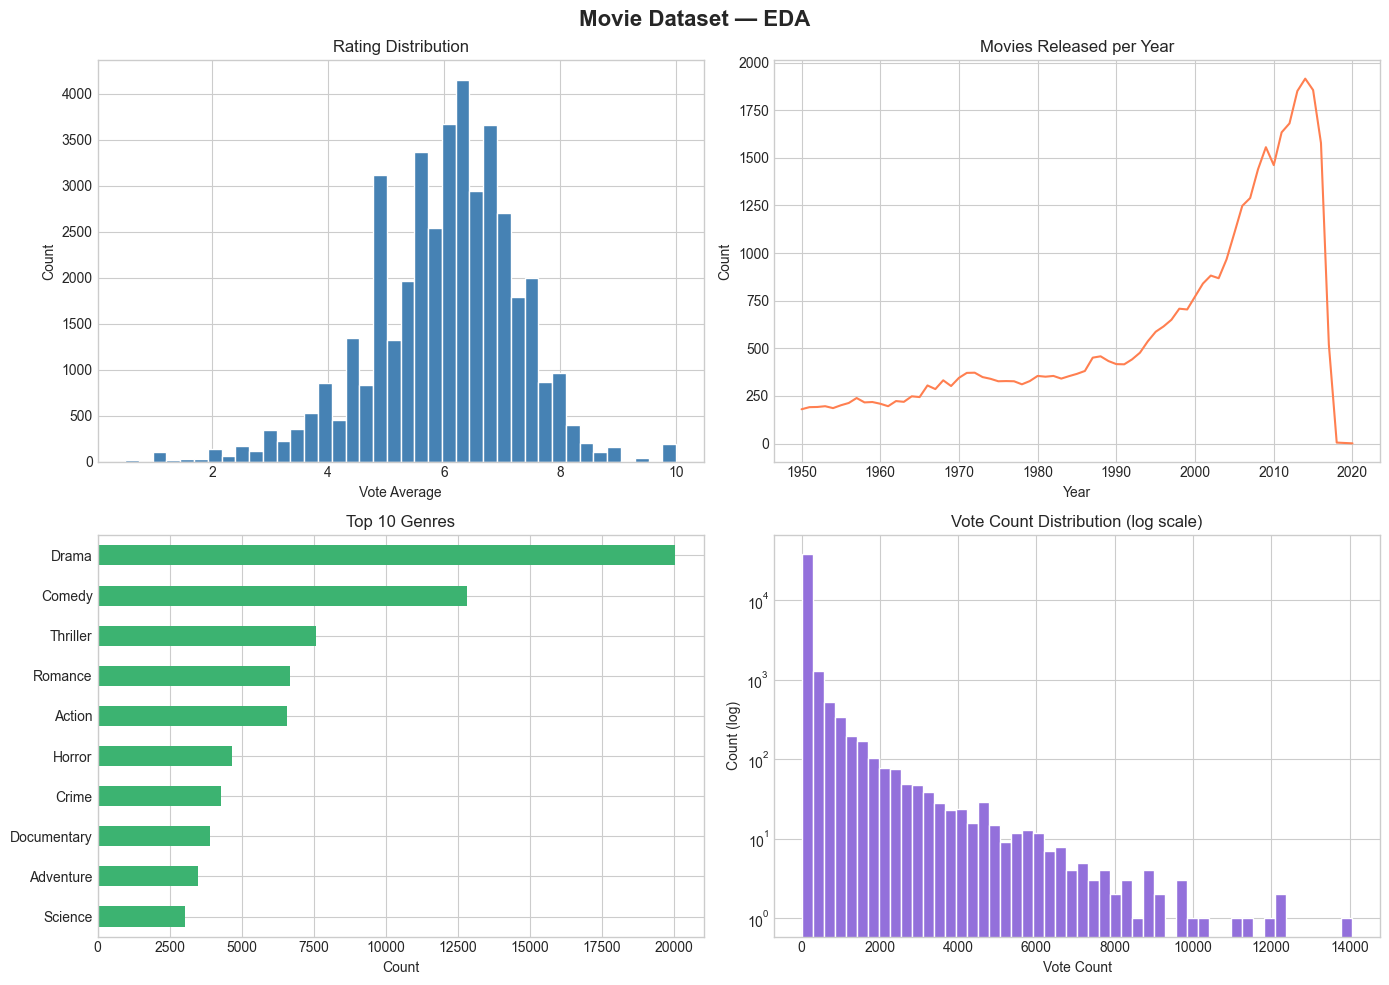

✅ EDA plots saved to static/eda_plots.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Movie Dataset — EDA', fontsize=16, fontweight='bold')

# Rating distribution
axes[0,0].hist(df[df['vote_average']>0]['vote_average'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Vote Average')
axes[0,0].set_ylabel('Count')

# Movies per year
year_counts = df['year'].dropna().astype(int).value_counts().sort_index()
year_counts[year_counts.index >= 1950].plot(ax=axes[0,1], color='coral')
axes[0,1].set_title('Movies Released per Year')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Count')

# Top genres
all_genres = []
for g in df['genres_clean']:
    all_genres.extend(g.split())
genre_series = pd.Series(all_genres).value_counts().head(10)
genre_series.plot(kind='barh', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Top 10 Genres')
axes[1,0].set_xlabel('Count')
axes[1,0].invert_yaxis()

# Vote count distribution (log scale)
axes[1,1].hist(df[df['vote_count']>0]['vote_count'], bins=50, color='mediumpurple', edgecolor='white')
axes[1,1].set_yscale('log')
axes[1,1].set_title('Vote Count Distribution (log scale)')
axes[1,1].set_xlabel('Vote Count')
axes[1,1].set_ylabel('Count (log)')

plt.tight_layout()
plt.savefig('../static/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved to static/eda_plots.png')

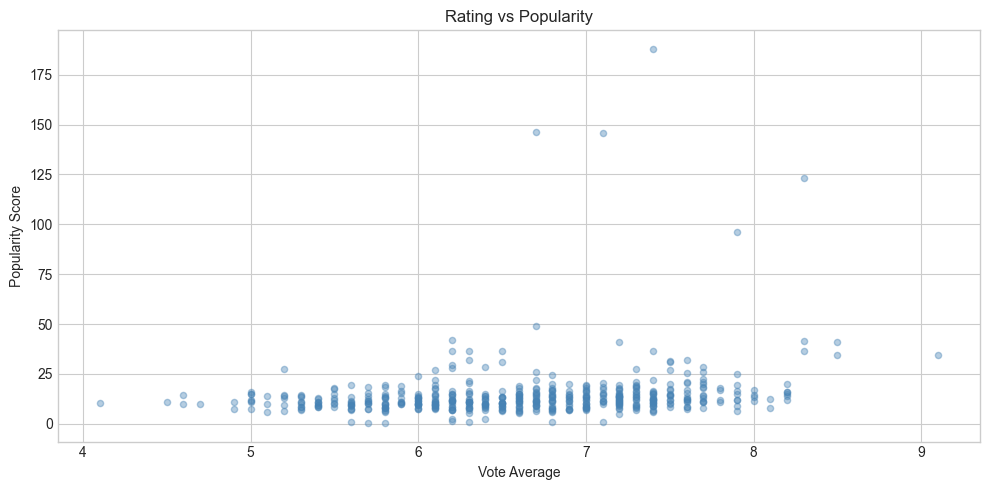

In [8]:
# Rating vs Popularity scatter
popular = df[(df['vote_count'] > 500) & (df['vote_average'] > 0)].sample(500, random_state=42)
plt.figure(figsize=(10, 5))
plt.scatter(popular['vote_average'], popular['popularity'], alpha=0.4, color='steelblue', s=20)
plt.xlabel('Vote Average')
plt.ylabel('Popularity Score')
plt.title('Rating vs Popularity')
plt.tight_layout()
plt.show()

## 5. Method 1 — Weighted Rating (IMDB Formula)

$$\text{Score} = \frac{v}{v+m} \times R + \frac{m}{v+m} \times C$$

Where:
- **v** = number of votes for the movie  
- **R** = average rating of the movie  
- **m** = minimum votes required (80th percentile)  
- **C** = mean rating across all movies

In [9]:
C = df['vote_average'].mean()
m = df['vote_count'].quantile(0.80)
print(f'Mean Rating (C): {C:.2f}')
print(f'Min Votes threshold (m): {m:.0f}')

def weighted_rating(row, m=m, C=C):
    v = row['vote_count']
    R = row['vote_average']
    return (v / (v + m)) * R + (m / (v + m)) * C

df['weighted_score'] = df.apply(weighted_rating, axis=1)
print('✅ Weighted scores computed')

Mean Rating (C): 5.64
Min Votes threshold (m): 51
✅ Weighted scores computed


In [10]:
def get_top_movies(genre=None, year_from=None, year_to=None, top_n=10, min_votes=None):
    mv = m if min_votes is None else min_votes
    filtered = df[df['vote_count'] >= mv].copy()
    if genre:
        filtered = filtered[filtered['genres_clean'].str.contains(genre, case=False, na=False)]
    if year_from:
        filtered = filtered[filtered['year'] >= year_from]
    if year_to:
        filtered = filtered[filtered['year'] <= year_to]
    top = filtered.nlargest(top_n, 'weighted_score')[['title','genres_clean','year','vote_average','vote_count','weighted_score']]
    top = top.reset_index(drop=True)
    top.index += 1
    top['year'] = top['year'].fillna(0).astype(int)
    return top

print('🏆 Top 10 Movies of All Time')
get_top_movies(top_n=10)

🏆 Top 10 Movies of All Time


,title,genres_clean,year,vote_average,vote_count,weighted_score
1,Dilwale Dulhania Le Jayenge,Comedy Drama Romance,1995,9.1,661.0,8.852083
2,The Shawshank Redemption,Drama Crime,1994,8.5,8358.0,8.482648
3,The Godfather,Drama Crime,1972,8.5,6024.0,8.475981
4,Your Name.,Romance Animation Drama,2016,8.5,1030.0,8.365017
5,The Dark Knight,Drama Action Crime Thriller,2008,8.3,12269.0,8.288984
6,Fight Club,Drama,1999,8.3,9678.0,8.286050
7,Pulp Fiction,Thriller Crime,1994,8.3,8670.0,8.284438
8,Schindler's List,Drama History War,1993,8.3,4436.0,8.269753
9,Whiplash,Drama,2014,8.3,4376.0,8.269343
10,Spirited Away,Fantasy Adventure Animation Family,2001,8.3,3968.0,8.266231


In [11]:
print('🎬 Top Action Movies (2000–2020)')
get_top_movies(genre='Action', year_from=2000, year_to=2020, top_n=10)

🎬 Top Action Movies (2000–2020)


,title,genres_clean,year,vote_average,vote_count,weighted_score
1,The Dark Knight,Drama Action Crime Thriller,2008,8.3,12269.0,8.288984
2,Inception,Action Thriller Science Fiction Mystery Adventure,2010,8.1,14075.0,8.091114
3,The Lord of the Rings: The Return of the King,Adventure Fantasy Action,2003,8.1,8226.0,8.084835
4,Band of Brothers,Action Drama War,2001,8.2,725.0,8.031679
5,The Lord of the Rings: The Fellowship of the Ring,Adventure Fantasy Action,2001,8.0,8892.0,7.986535
6,The Lord of the Rings: The Two Towers,Adventure Fantasy Action,2002,8.0,7641.0,7.984345
7,Oldboy,Drama Thriller Mystery Action,2003,8.0,2000.0,7.941289
8,Guardians of the Galaxy,Action Science Fiction Adventure,2014,7.9,10014.0,7.888543
9,Inglourious Basterds,Drama Action Thriller War,2009,7.9,6598.0,7.882656
10,Gladiator,Action Drama Adventure,2000,7.9,5566.0,7.879470


## 6. Method 2 — Content-Based Filtering (TF-IDF)

In [12]:
# Build soup: overview + genres (2x weighted)
df['soup'] = (
    df['overview'].fillna('') + ' ' +
    df['genres_clean'] + ' ' +
    df['genres_clean']
)

# TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df['soup'])

print(f'✅ TF-IDF Matrix: {tfidf_matrix.shape}')
print(f'   Sparsity: {100*(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1])):.1f}%')

# Reverse index
indices = pd.Series(df.index, index=df['title'].str.lower()).drop_duplicates()

✅ TF-IDF Matrix: (44506, 15000)
   Sparsity: 99.8%


In [13]:
def get_content_recommendations(title, top_n=10):
    title_lower = title.lower().strip()
    if title_lower not in indices:
        matches = [t for t in indices.index if title_lower in t]
        if not matches:
            return f"'{title}' not found."
        title_lower = matches[0]
        print(f"Closest match: '{df.loc[indices[title_lower].iloc[0] if hasattr(indices[title_lower],'iloc') else indices[title_lower], 'title']}'")
    idx_val = indices[title_lower]
    idx = int(idx_val.iloc[0]) if hasattr(idx_val, 'iloc') else int(idx_val)
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sim_scores[idx] = 0
    top_idx = np.argsort(sim_scores)[::-1][:top_n]
    top_idx = [i for i in top_idx if i < len(df)]
    results = df.iloc[top_idx][['title','genres_clean','year','vote_average','weighted_score']].copy()
    results['similarity'] = sim_scores[top_idx].round(3)
    results['year'] = results['year'].fillna(0).astype(int)
    return results.reset_index(drop=True)

print('🔍 Content-Based Recommendations for "The Dark Knight"')
get_content_recommendations('The Dark Knight', top_n=10)

🔍 Content-Based Recommendations for "The Dark Knight"


,title,genres_clean,year,vote_average,weighted_score,similarity
0,Ricochet,Action Crime Thriller,1991,5.9,5.799113,0.366
1,The Dark Knight Rises,Action Crime Drama Thriller,2012,7.6,7.589262,0.340
2,Underworld U.S.A.,Action Crime Thriller,1961,6.6,5.821951,0.319
3,Twelve,Thriller Drama Action Crime,2010,6.0,5.877219,0.318
4,Policewomen,Drama Action Crime,1974,6.8,5.703387,0.300
5,Initial D,Action Crime Thriller Drama,2005,6.3,5.952401,0.296
6,Kidnapping Mr. Heineken,Drama Action Crime Thriller,2015,5.8,5.766323,0.289
7,Postman Blues,Crime Drama Action,1997,6.6,5.769201,0.286
8,The Last Bullet,Action Crime Thriller,1973,8.3,5.786720,0.286
9,Hitman: Agent 47,Action Crime Thriller,2015,5.5,5.505740,0.285


In [14]:
print('🔍 Content-Based Recommendations for "Toy Story"')
get_content_recommendations('Toy Story', top_n=10)

🔍 Content-Based Recommendations for "Toy Story"


,title,genres_clean,year,vote_average,weighted_score,similarity
0,Toy Story 2,Animation Comedy Family,1999,7.3,7.278634,0.507
1,Toy Story 3,Animation Family Comedy,2010,7.6,7.578992,0.477
2,Small Fry,Animation Family,2011,6.8,6.449603,0.323
3,Botsman i Popugay,Animation Comedy Family,1982,7.0,5.665056,0.297
4,Banana,Animation Comedy Family,2010,7.2,6.780963,0.289
5,The 40 Year Old Virgin,Comedy Romance,2005,6.2,6.186182,0.285
6,Andy Hardy's Blonde Trouble,Comedy Family Romance,1944,6.3,5.663828,0.270
7,Mr. Bug Goes to Town,Animation Comedy Family,1941,5.7,5.648900,0.270
8,Lorenzo,Animation Comedy Family,2004,6.8,5.888968,0.268
9,The Champ,Drama,1931,6.8,5.874733,0.267


## 7. Method 3 — Hybrid Recommender

In [15]:
def get_hybrid_recommendations(title, top_n=10):
    title_lower = title.lower().strip()
    if title_lower not in indices:
        matches = [t for t in indices.index if title_lower in t]
        if not matches:
            return f"'{title}' not found."
        title_lower = matches[0]
    idx_val = indices[title_lower]
    idx = int(idx_val.iloc[0]) if hasattr(idx_val, 'iloc') else int(idx_val)
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sim_scores[idx] = 0
    sim_norm = sim_scores / (sim_scores.max() + 1e-9)
    score_norm = (df['weighted_score'] - df['weighted_score'].min()) / \
                 (df['weighted_score'].max() - df['weighted_score'].min() + 1e-9)
    hybrid = 0.6 * sim_norm + 0.4 * score_norm.values
    top_idx = np.argsort(hybrid)[::-1][:top_n]
    results = df.iloc[top_idx][['title','genres_clean','year','vote_average','weighted_score']].copy()
    results['hybrid_score'] = hybrid[top_idx].round(4)
    results['year'] = results['year'].fillna(0).astype(int)
    return results.reset_index(drop=True)

print('⚡ Hybrid Recommendations for "Inception"')
get_hybrid_recommendations('Inception', top_n=10)

⚡ Hybrid Recommendations for "Inception"


,title,genres_clean,year,vote_average,weighted_score,hybrid_score
0,Minority Report,Action Thriller Science Fiction Mystery,2002,7.1,7.072543,0.8854
1,2001: A Space Odyssey,Science Fiction Mystery Adventure,1968,7.9,7.863110,0.8691
2,Cube,Thriller Science Fiction Mystery,1997,6.9,6.844169,0.7856
3,Cypher,Thriller Science Fiction Mystery,2002,6.7,6.480902,0.7749
4,Gattaca,Thriller Science Fiction Mystery Romance,1997,7.5,7.449965,0.7565
5,Mad Max,Adventure Action Thriller Science Fiction,1979,6.6,6.561884,0.7225
6,Ticking Clock,Action Thriller Science Fiction Mystery,2011,4.8,5.420042,0.7204
7,Signs,Drama Thriller Science Fiction Mystery,2002,6.4,6.376826,0.7204
8,Senn,Science Fiction Mystery Adventure,2013,5.4,5.617552,0.7098
9,Source Code,Thriller Science Fiction Mystery,2011,7.1,7.073415,0.7020


## 8. Visualize Similarity Heatmap

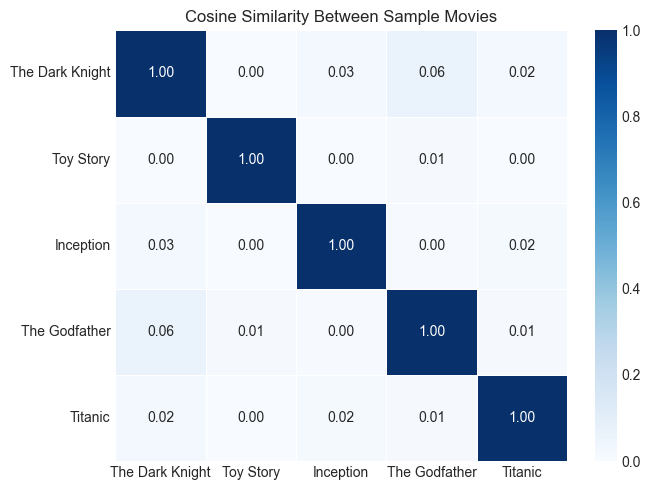

✅ Heatmap saved to static/similarity_heatmap.png


In [16]:
sample_titles = ['The Dark Knight', 'Toy Story', 'Inception', 'The Godfather', 'Titanic']
sample_indices = []
valid_titles = []
for t in sample_titles:
    tl = t.lower()
    if tl in indices:
        iv = indices[tl]
        idx = int(iv.iloc[0]) if hasattr(iv, 'iloc') else int(iv)
        sample_indices.append(idx)
        valid_titles.append(t)

sample_matrix = tfidf_matrix[sample_indices]
sim_matrix = cosine_similarity(sample_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', xticklabels=valid_titles,
            yticklabels=valid_titles, cmap='Blues', linewidths=0.5)
plt.title('Cosine Similarity Between Sample Movies')
plt.tight_layout()
plt.savefig('../static/similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap saved to static/similarity_heatmap.png')

## 9. Summary

| Method | Input | Output | Best For |
|--------|-------|--------|----------|
| Weighted Rating | None (global) | Top N movies | Cold start / homepage |
| Content-Based | Movie title | Similar movies | 'More like this' |
| Hybrid | Movie title | Similar + high-quality | Best overall results |

**Next Steps:**
- Add collaborative filtering using user ratings data
- Deploy as a Flask web application (see `app/app.py`)
- Extend with cast/crew features from credits dataset